In [3]:
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)

1.26.4
3.0.3


In [5]:
column_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country",
    "income"
]

train_df = pd.read_csv(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/AI-Fairness-Project/adult/adult.data",
    names=column_names,
    na_values="?",
    skipinitialspace=True
)

test_df = pd.read_csv(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/AI-Fairness-Project/adult/adult.test",
    names=column_names,
    na_values="?",
    skipinitialspace=True,
    skiprows=1
)

test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

df = pd.concat([train_df, test_df], ignore_index=True)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df = df.dropna().copy()

df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

df = df.dropna(subset=["income"])
df["income"] = df["income"].astype(int)

print(df.shape)
df.head()

(45222, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [7]:
print(df["income"].value_counts())
print(df["sex"].value_counts())
print(df["race"].value_counts())

income
0    34014
1    11208
Name: count, dtype: int64
sex
Male      30527
Female    14695
Name: count, dtype: int64
race
White                 38903
Black                  4228
Asian-Pac-Islander     1303
Amer-Indian-Eskimo      435
Other                   353
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference, equalized_odds_difference
from fairlearn.postprocessing import ThresholdOptimizer

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Matplotlib is building the font cache; this may take a moment.


In [9]:
X = df.drop("income", axis=1)
y = df["income"]

sensitive_feature = X["sex"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Numeric: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


/var/folders/ps/rftsht2x53598lm1d_gqrcbr0000gn/T/ipykernel_68270/1766376231.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [10]:
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive_feature,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Logistic Regression

In [12]:
log_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Model Performance

In [13]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_prob))

print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression Results
Accuracy: 0.8449972360420122
Precision: 0.734375
Recall: 0.5869759143621767
F1 Score: 0.6524541398116014
ROC AUC: 0.9020240257125373

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      6803
           1       0.73      0.59      0.65      2242

    accuracy                           0.84      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.84      0.84      9045



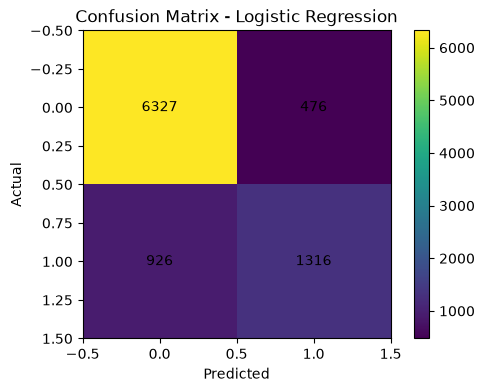

In [14]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [15]:
metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "precision": precision_score,
        "recall": recall_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=log_pred,
    sensitive_features=sensitive_test
)

metric_frame.by_group

,accuracy,precision,recall,selection_rate
sex,,,,
Female,0.915214,0.725225,0.456091,0.074397
Male,0.810427,0.735669,0.611435,0.259033


Fairness gap

In [16]:
dp_diff = demographic_parity_difference(
    y_test,
    log_pred,
    sensitive_features=sensitive_test
)

eo_diff = equalized_odds_difference(
    y_test,
    log_pred,
    sensitive_features=sensitive_test
)

print("Demographic Parity Difference:", dp_diff)
print("Equalized Odds Difference:", eo_diff)

Demographic Parity Difference: 0.18463638000259208
Equalized Odds Difference: 0.15534396993477967


Plot fairness by gender

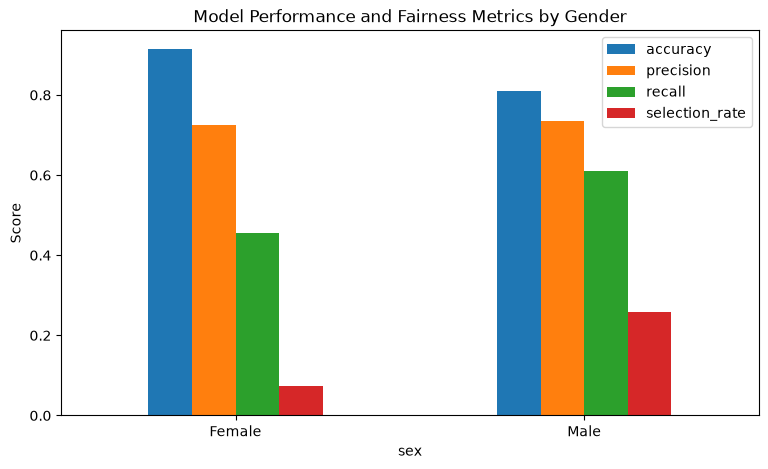

In [17]:
fairness_df = metric_frame.by_group.reset_index()

fairness_df.plot(
    x="sex",
    y=["accuracy", "precision", "recall", "selection_rate"],
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance and Fairness Metrics by Gender")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Random Forest

In [18]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [19]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Results
Accuracy: 0.852294085129906
Precision: 0.7417289220917823
Recall: 0.6199821587867975
F1 Score: 0.6754130223517979
ROC AUC: 0.9038173587425289


In [20]:
rf_metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "precision": precision_score,
        "recall": recall_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=rf_pred,
    sensitive_features=sensitive_test
)

rf_metric_frame.by_group

,accuracy,precision,recall,selection_rate
sex,,,,
Female,0.922587,0.756303,0.509915,0.079759
Male,0.817687,0.739609,0.640551,0.269922


In [21]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ],
    "Demographic_Parity_Difference": [
        demographic_parity_difference(y_test, log_pred, sensitive_features=sensitive_test),
        demographic_parity_difference(y_test, rf_pred, sensitive_features=sensitive_test)
    ],
    "Equalized_Odds_Difference": [
        equalized_odds_difference(y_test, log_pred, sensitive_features=sensitive_test),
        equalized_odds_difference(y_test, rf_pred, sensitive_features=sensitive_test)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Demographic_Parity_Difference,Equalized_Odds_Difference
0,Logistic Regression,0.844997,0.734375,0.586976,0.652454,0.902024,0.184636,0.155344
1,Random Forest,0.852294,0.741729,0.619982,0.675413,0.903817,0.190164,0.130636


In [22]:
mitigator = ThresholdOptimizer(
    estimator=log_model,
    constraints="demographic_parity",
    predict_method="predict_proba",
    prefit=True
)

mitigator.fit(
    X_train,
    y_train,
    sensitive_features=sensitive_train
)

mitigated_pred = mitigator.predict(
    X_test,
    sensitive_features=sensitive_test
)

In [23]:
print("Mitigated Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, mitigated_pred))
print("Precision:", precision_score(y_test, mitigated_pred))
print("Recall:", recall_score(y_test, mitigated_pred))
print("F1 Score:", f1_score(y_test, mitigated_pred))

print("\nClassification Report:")
print(classification_report(y_test, mitigated_pred))

Mitigated Logistic Regression Results
Accuracy: 0.8288557213930349
Precision: 0.7475035663338089
Recall: 0.46743978590544155
F1 Score: 0.575192096597146

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      6803
           1       0.75      0.47      0.58      2242

    accuracy                           0.83      9045
   macro avg       0.80      0.71      0.73      9045
weighted avg       0.82      0.83      0.81      9045



In [24]:
mitigated_metric_frame = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "precision": precision_score,
        "recall": recall_score,
        "selection_rate": selection_rate
    },
    y_true=y_test,
    y_pred=mitigated_pred,
    sensitive_features=sensitive_test
)

mitigated_metric_frame.by_group

,accuracy,precision,recall,selection_rate
sex,,,,
Female,0.900804,0.560510,0.747875,0.157842
Male,0.793433,0.842105,0.415034,0.153605


In [25]:
before_after = pd.DataFrame({
    "Model": ["Before Mitigation", "After Mitigation"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, mitigated_pred)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, mitigated_pred)
    ],
    "Demographic Parity Difference": [
        demographic_parity_difference(y_test, log_pred, sensitive_features=sensitive_test),
        demographic_parity_difference(y_test, mitigated_pred, sensitive_features=sensitive_test)
    ],
    "Equalized Odds Difference": [
        equalized_odds_difference(y_test, log_pred, sensitive_features=sensitive_test),
        equalized_odds_difference(y_test, mitigated_pred, sensitive_features=sensitive_test)
    ]
})

before_after

,Model,Accuracy,F1,Demographic Parity Difference,Equalized Odds Difference
0,Before Mitigation,0.844997,0.652454,0.184636,0.155344
1,After Mitigation,0.828856,0.575192,0.004237,0.332841


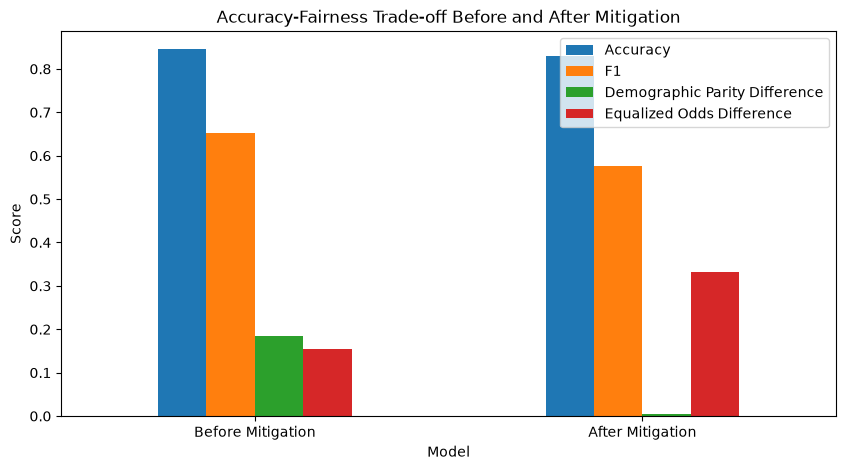

In [26]:
before_after.plot(
    x="Model",
    y=["Accuracy", "F1", "Demographic Parity Difference", "Equalized Odds Difference"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Accuracy-Fairness Trade-off Before and After Mitigation")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

RESEARCH

NOTES

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference,
    false_positive_rate,
    false_negative_rate
)

from fairlearn.postprocessing import ThresholdOptimizer

In [28]:
df = df.dropna().copy()

df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

df = df.dropna(subset=["income"])
df["income"] = df["income"].astype(int)

print(df.shape)
df.head()

(0, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income


In [29]:
print("Dataset shape:", df.shape)

print("\nTarget distribution:")
print(df["income"].value_counts(normalize=True))

print("\nGender distribution:")
print(df["sex"].value_counts(normalize=True))

print("\nRace distribution:")
print(df["race"].value_counts(normalize=True))

Dataset shape: (0, 15)

Target distribution:
Series([], Name: proportion, dtype: float64)

Gender distribution:
Series([], Name: proportion, dtype: float64)

Race distribution:
Series([], Name: proportion, dtype: float64)


In [31]:
df["income"].unique()

array([], dtype=int64)

In [32]:
df = pd.concat([train_df, test_df], ignore_index=True)

df = df.dropna().copy()

df["income"] = (
    df["income"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

print(df["income"].unique())

df["income"] = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

df = df.dropna(subset=["income"])
df["income"] = df["income"].astype(int)

print(df.shape)
print(df["income"].value_counts())

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
(45222, 15)
income
0    34014
1    11208
Name: count, dtype: int64


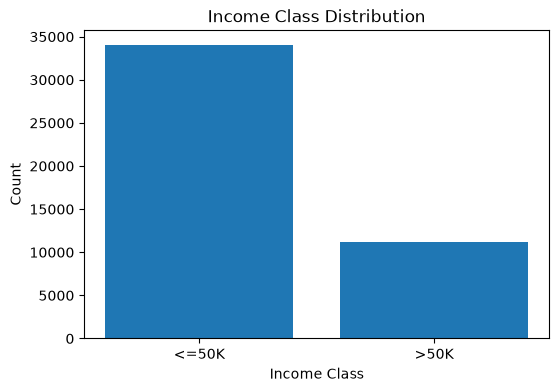

In [33]:
target_counts = df["income"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["<=50K", ">50K"], target_counts.values)
plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Count")
plt.show()

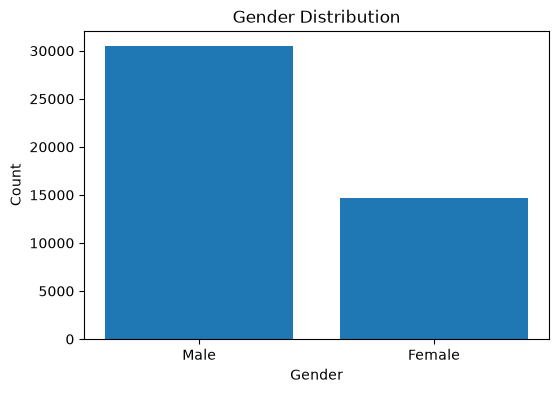

In [34]:
gender_counts = df["sex"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(gender_counts.index, gender_counts.values)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

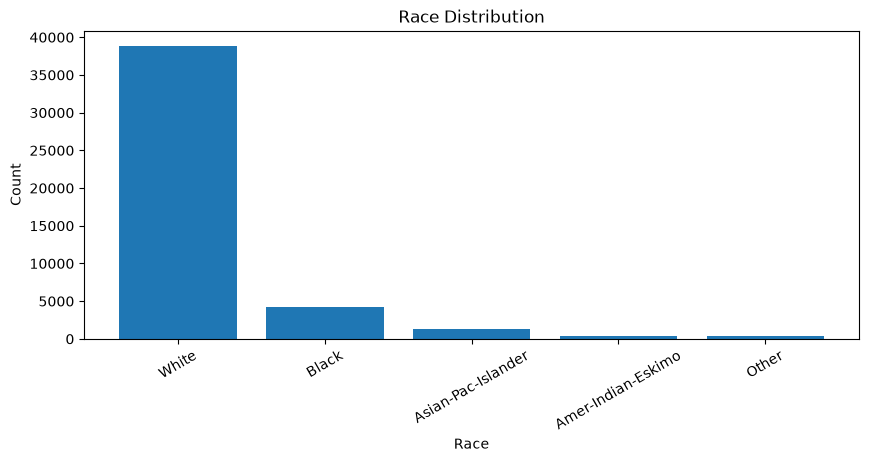

In [35]:
race_counts = df["race"].value_counts()

plt.figure(figsize=(10, 4))
plt.bar(race_counts.index, race_counts.values)
plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [36]:
X = df.drop("income", axis=1)
y = df["income"]

sensitive_gender = X["sex"]
sensitive_race = X["race"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Numeric features: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


/var/folders/ps/rftsht2x53598lm1d_gqrcbr0000gn/T/ipykernel_68270/1270294668.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, gender_train, gender_test, race_train, race_test = train_test_split(
    X,
    y,
    sensitive_gender,
    sensitive_race,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [38]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42)
}

In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42)
}

In [42]:
model_results = []
trained_models = {}

for name, clf in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", clf)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    trained_models[name] = pipeline
    
    model_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "Gender_Demographic_Parity_Difference": demographic_parity_difference(
            y_test, y_pred, sensitive_features=gender_test
        ),
        "Gender_Equalized_Odds_Difference": equalized_odds_difference(
            y_test, y_pred, sensitive_features=gender_test
        ),
        "Race_Demographic_Parity_Difference": demographic_parity_difference(
            y_test, y_pred, sensitive_features=race_test
        ),
        "Race_Equalized_Odds_Difference": equalized_odds_difference(
            y_test, y_pred, sensitive_features=race_test
        )
    })

results_df = pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Gender_Demographic_Parity_Difference,Gender_Equalized_Odds_Difference,Race_Demographic_Parity_Difference,Race_Equalized_Odds_Difference
0,Logistic Regression,0.844997,0.734375,0.586976,0.652454,0.902024,0.184636,0.155344,0.219527,0.490107
1,Random Forest,0.851631,0.739362,0.619982,0.674430,0.904814,0.190153,0.123911,0.154980,0.268836


MAIN PROJECT

In [43]:
best_model_name = results_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [44]:
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:,1]

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6803
           1       0.74      0.62      0.67      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.77      0.79      9045
weighted avg       0.85      0.85      0.85      9045



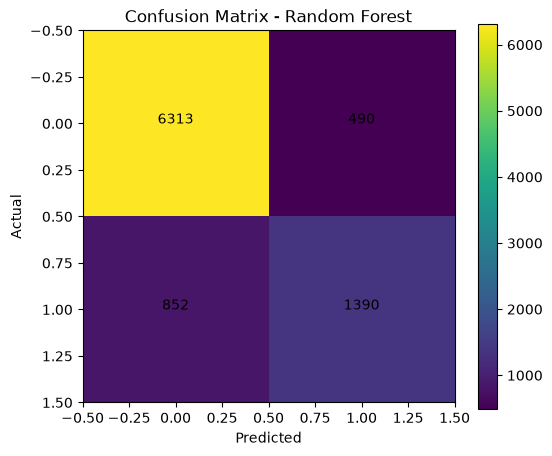

In [46]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha='center')

plt.show()

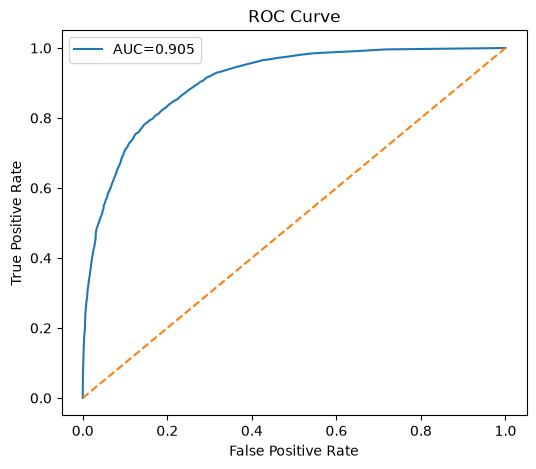

In [47]:
from sklearn.metrics import roc_curve, auc

fpr,tpr,_=roc_curve(y_test,best_prob)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [48]:
from fairlearn.metrics import MetricFrame
from fairlearn.metrics import selection_rate
from fairlearn.metrics import false_positive_rate
from fairlearn.metrics import false_negative_rate

gender_metrics = MetricFrame(
    metrics={
        "Accuracy":accuracy_score,
        "Precision":precision_score,
        "Recall":recall_score,
        "Selection Rate":selection_rate,
        "False Positive Rate":false_positive_rate,
        "False Negative Rate":false_negative_rate
    },
    y_true=y_test,
    y_pred=best_pred,
    sensitive_features=gender_test
)

gender_metrics.by_group

,Accuracy,Precision,Recall,Selection Rate,False Positive Rate,False Negative Rate
sex,,,,,,
Female,0.923257,0.758333,0.515581,0.080429,0.022045,0.484419
Male,0.816367,0.736585,0.639492,0.270582,0.103547,0.360508


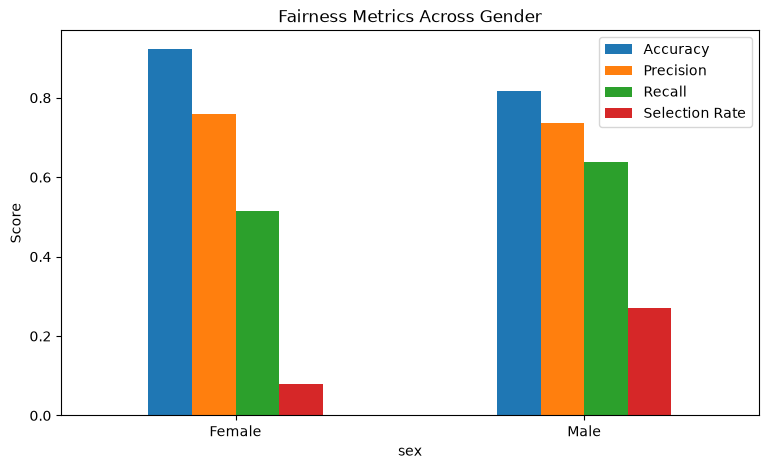

In [49]:
gender_df = gender_metrics.by_group.reset_index()

gender_df.plot(
    x="sex",
    y=[
        "Accuracy",
        "Precision",
        "Recall",
        "Selection Rate"
    ],
    kind="bar",
    figsize=(9,5)
)

plt.title("Fairness Metrics Across Gender")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [50]:
race_metrics = MetricFrame(
    metrics={
        "Accuracy":accuracy_score,
        "Precision":precision_score,
        "Recall":recall_score,
        "Selection Rate":selection_rate,
        "False Positive Rate":false_positive_rate,
        "False Negative Rate":false_negative_rate
    },
    y_true=y_test,
    y_pred=best_pred,
    sensitive_features=race_test
)

race_metrics.by_group

,Accuracy,Precision,Recall,Selection Rate,False Positive Rate,False Negative Rate
race,,,,,,
Amer-Indian-Eskimo,0.895833,0.375000,0.375000,0.083333,0.056818,0.625000
Asian-Pac-Islander,0.843284,0.746032,0.643836,0.235075,0.082051,0.356164
Black,0.921084,0.779412,0.504762,0.080094,0.020161,0.495238
Other,0.926471,0.833333,0.555556,0.088235,0.016949,0.444444
White,0.843122,0.738905,0.626282,0.223467,0.079237,0.373718


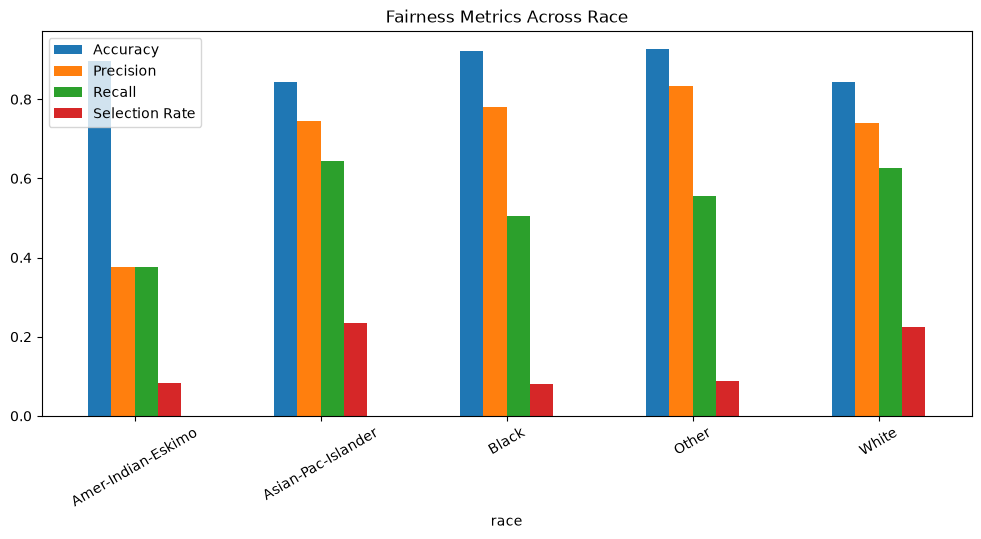

In [51]:
race_df = race_metrics.by_group.reset_index()

race_df.plot(
    x="race",
    y=[
        "Accuracy",
        "Precision",
        "Recall",
        "Selection Rate"
    ],
    kind="bar",
    figsize=(12,5)
)

plt.xticks(rotation=30)

plt.title("Fairness Metrics Across Race")

plt.show()

In [52]:
fairness_summary = pd.DataFrame({

    "Sensitive Attribute":[
        "Gender",
        "Race"
    ],

    "Demographic Parity Difference":[

        demographic_parity_difference(
            y_test,
            best_pred,
            sensitive_features=gender_test
        ),

        demographic_parity_difference(
            y_test,
            best_pred,
            sensitive_features=race_test
        )
    ],

    "Equalized Odds Difference":[

        equalized_odds_difference(
            y_test,
            best_pred,
            sensitive_features=gender_test
        ),

        equalized_odds_difference(
            y_test,
            best_pred,
            sensitive_features=race_test
        )

    ]

})

fairness_summary

,Sensitive Attribute,Demographic Parity Difference,Equalized Odds Difference
0,Gender,0.190153,0.123911
1,Race,0.154980,0.268836


In [53]:
from fairlearn.postprocessing import ThresholdOptimizer

base_model = trained_models["Logistic Regression"]

base_pred = base_model.predict(X_test)

mitigator = ThresholdOptimizer(
    estimator=base_model,
    constraints="demographic_parity",
    predict_method="predict_proba",
    prefit=True
)

mitigator.fit(
    X_train,
    y_train,
    sensitive_features=gender_train
)

mitigated_pred = mitigator.predict(
    X_test,
    sensitive_features=gender_test
)

In [54]:
before_after = pd.DataFrame({
    "Model": ["Before Mitigation", "After Mitigation"],
    "Accuracy": [
        accuracy_score(y_test, base_pred),
        accuracy_score(y_test, mitigated_pred)
    ],
    "Precision": [
        precision_score(y_test, base_pred),
        precision_score(y_test, mitigated_pred)
    ],
    "Recall": [
        recall_score(y_test, base_pred),
        recall_score(y_test, mitigated_pred)
    ],
    "F1": [
        f1_score(y_test, base_pred),
        f1_score(y_test, mitigated_pred)
    ],
    "Demographic Parity Difference": [
        demographic_parity_difference(y_test, base_pred, sensitive_features=gender_test),
        demographic_parity_difference(y_test, mitigated_pred, sensitive_features=gender_test)
    ],
    "Equalized Odds Difference": [
        equalized_odds_difference(y_test, base_pred, sensitive_features=gender_test),
        equalized_odds_difference(y_test, mitigated_pred, sensitive_features=gender_test)
    ]
})

before_after

,Model,Accuracy,Precision,Recall,F1,Demographic Parity Difference,Equalized Odds Difference
0,Before Mitigation,0.844997,0.734375,0.586976,0.652454,0.184636,0.155344
1,After Mitigation,0.829187,0.748396,0.468332,0.576132,0.004072,0.331782


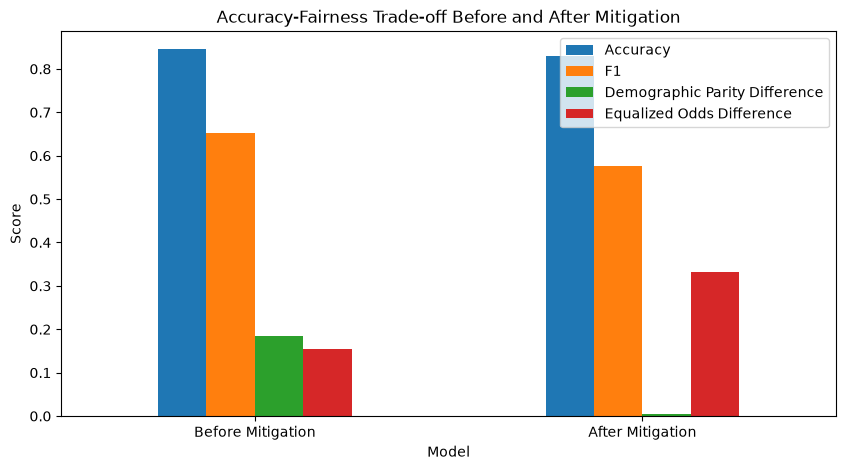

In [55]:
before_after.plot(
    x="Model",
    y=["Accuracy", "F1", "Demographic Parity Difference", "Equalized Odds Difference"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Accuracy-Fairness Trade-off Before and After Mitigation")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [56]:
rf_model = trained_models["Random Forest"]

feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
1,num__fnlwgt,0.170253
0,num__age,0.154208
3,num__capital_gain,0.098070
5,num__hours_per_week,0.082725
31,cat__marital_status_Married-civ-spouse,0.071915
2,num__education_num,0.059528
50,cat__relationship_Husband,0.041430
4,num__capital_loss,0.031405
33,cat__marital_status_Never-married,0.018571
39,cat__occupation_Exec-managerial,0.016817


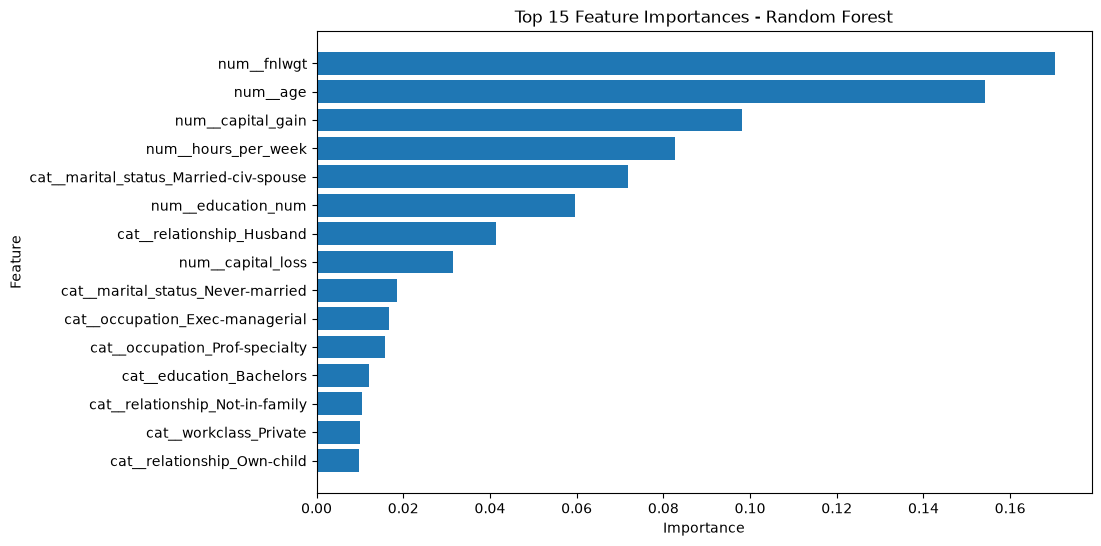

In [57]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

# Final Audit Conclusion

This project evaluated machine learning models not only by predictive performance, but also by fairness, transparency, and accountability.

The results showed that Logistic Regression and Random Forest achieved strong predictive performance on the Adult Census Income dataset. However, fairness evaluation revealed demographic disparities across gender and race groups, especially in selection rates and error rates.

Fairness mitigation using threshold optimization reduced demographic parity difference, but also changed other performance and fairness metrics. This shows an important accountability issue: improving one fairness criterion can worsen another, so fairness cannot be evaluated using a single metric.

Feature importance analysis showed which variables most influenced model predictions, supporting transparency and interpretability.

Overall, this project demonstrates an end-to-end algorithmic accountability workflow: model training, fairness auditing, mitigation, explainability, and reporting.